<a href="https://colab.research.google.com/github/bah862696-coder/DI-Bootcamp/blob/master/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
Large Language Models (LLMs) are deep learning models trained on massive datasets to understand and generate human-like text. They are designed to solve a wide variety of Natural Language Processing (NLP) tasks, such as translation, summarization, sentiment analysis, and creative writing, by predicting the probability of a sequence of words.

### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [ ]:
%pip install --quiet transformers matplotlib --upgrade


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 2. Loading a pretrained model and tokenizer
model_name = 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


Tokenization is the process of breaking down a string of text into smaller units called 'tokens' (which can be words, subwords, or characters). These tokens are then mapped to unique numerical IDs that the model can process mathematically.

Original Text: Natural Language Processing is fascinating!
Tokens: ['Natural', 'ĠLanguage', 'ĠProcessing', 'Ġis', 'Ġfascinating', '!']
Token IDs: [35364, 15417, 28403, 318, 13899, 0]


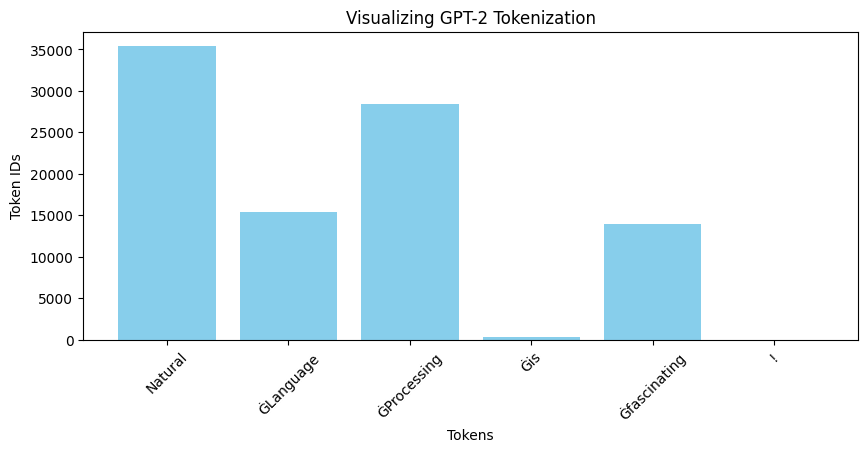

In [2]:
text = "Natural Language Processing is fascinating!"

if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

# 2. Tokenize input text
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

# 3. Visualizing the tokenization process
x_label = "Tokens"
y_label = "Token IDs"
title = "Visualizing GPT-2 Tokenization"

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()

## 🌟 Exercise 3 · Token IDs and special prefixes


In [3]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

print("Token to ID Mapping:")
for token, token_id in zip(tokens, token_ids):
    print(f"Token: {token: <12} | ID: {token_id}")

Token to ID Mapping:
Token: Natural      | ID: 35364
Token: ĠLanguage    | ID: 15417
Token: ĠProcessing  | ID: 28403
Token: Ġis          | ID: 318
Token: Ġfascinating | ID: 13899
Token: !            | ID: 0


In GPT-style vocabularies (like Byte-Pair Encoding), the `Ġ` prefix is a special character used to represent a leading space. It allows the model to distinguish between a word that starts a sentence and the same word occurring in the middle of a sentence preceded by a space.

## 🌟 Exercise 4 · Pre-training vs. Fine-tuning

**Pre-training:** This is the initial phase where a model is trained on a massive, diverse dataset (like the whole internet) using self-supervised learning. The goal is to teach the model general language patterns, grammar, and facts. It learns to predict the next token in a sequence.

**Fine-tuning:** This is the second phase where the pre-trained model is further trained on a smaller, specific dataset for a particular task (like medical diagnosis, legal advice, or sentiment analysis). This process adapts the general knowledge of the model to follow specific instructions or excel in a niche domain.

Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [6]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "The future of Artificial Intelligence in education is"

if input_text is None:
    raise ValueError("Set `input_text` before generating.")

# Refined generation parameters
gen_kwargs = {
    "max_new_tokens": 60,
    "temperature": 0.8,
    "top_p": 0.95,
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
    "clean_up_tokenization_spaces": False,
    "generation_config": None  # This suppresses the deprecation and max_length warnings
}

output_ids = generator(input_text, **gen_kwargs)
output_text = output_ids[0]["generated_text"]

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

Input: The future of Artificial Intelligence in education is
Generated Output: The future of Artificial Intelligence in education is not yet clear. One question remains: Does AI make smarter, smarter people?

In his latest book, Artificial Intelligence: How We Can Achieve It, Elon Musk, the CEO of Tesla Motors, argues that AI will become "more efficient than humans." As Musk writes, "Autopilot


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?


Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)